In [1]:
import matplotlib.pyplot as plt
from os import environ
'''environ["OMP_NUM_THREADS"] = "1"
environ["OPENBLAS_NUM_THREADS"] = "1"
environ["MKL_NUM_THREADS"] = "1"
environ["VECLIB_MAXIMUM_THREADS"] = "1"
environ["NUMEXPR_NUM_THREADS"] = "1"'''
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from scipy.fftpack import fft, ifft
#from IPython import get_ipython;   
#from itertools import repeat, izip
#get_ipython().magic('reset -sf')
#plt.close('all')

n = 4000
sigma = 0.2
mu = 0.6
gammax = 0.0
r = 3.4


eff0 = 0.01


tmax = 2000


numtrial = 1

kbound =1

if __name__ == '__main__':


    myevalues = np.array([])
    
    for trial in range(0, numtrial):
        axx = np.zeros((n,n))
                    
        #construct random interaction matrix
        for i in range(0,n):
            for k in range(0,i):
                rand2 = np.random.uniform(0.0,1.0, 1)[0]
                rand3 = np.random.uniform(0.0,1.0, 1)[0]
                if rand2<0.5:
                    axx[i][k] = -mu/n-sigma/np.sqrt(n)
                if rand2>0.5:
                    axx[i][k] = -mu/n+sigma/np.sqrt(n)
                if rand3<0.5:
                    axx[k][i] = -mu/n-sigma/np.sqrt(n)
                if rand3>0.5:
                    axx[k][i] = -mu/n+sigma/np.sqrt(n)


            
        x = np.ones(n)*(1.0-1.0/r)
        step = 0
        t = 0
        #Numerical integration
        while t <= tmax:

            x = r*x*(1.0 -(1.0-mu)*x + axx.dot(x))*np.heaviside(r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)*np.heaviside(kbound-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0) + kbound*(1.0-np.heaviside(kbound-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)) + 0.0001

            step = step +1
            t = t + 1
            
        xstar = np.copy(x)

        print("Run complete")

        nstar = np.copy(n)
        for k in range(0,n):
            if x[k] <eff0 or x[k]>1-eff0:
                axx = np.delete(axx, k-(n-nstar), 0)
                axx = np.delete(axx, k-(n-nstar), 1)
                xstar = np.delete(xstar, k-(n-nstar), 0)
                #xstar = np.delete(xstar, k-(n-nstar), 1)
                nstar = nstar - 1
        

        
        id = np.identity(nstar)
            
        jac = np.zeros((nstar,nstar))

        for i in range(0,nstar):
            for j in range(0, nstar):
                jac[i][j] = r*xstar[i]*( axx[i][j] -(1.0-mu)*id[i][j] ) + id[i][j]

        print("Jacobian constructed")
        evaluesj, evectorsj = la.eig(jac)
        evaluesa, evectorsa = la.eig(axx)

        myevalues = np.append(myevalues, evaluesj)

        print("Eigenvalues found")



    
    #np.savetxt("lambdaversusr_sig0point2_n8000.csv", lambdavec, delimiter=",")
    #np.savetxt("rvecsim_sig0point2_n8000.csv", rvec, delimiter=",")

    








KeyboardInterrupt: 

C:\Users\josep\AppData\Local\Temp\ipykernel_17612\4053636568.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_17612\4053636568.py:113: RuntimeWarning: invalid value encountered in sqrt
  ax1.plot(myx, np.sqrt((1.0-mu)**2-myx**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
C:\Users\josep\AppData\Local\Temp\ipykernel_17612\4053636568.py:114: RuntimeWarning: invalid value encountered in sqrt
  ax1.plot(myx, -np.sqrt((1.0-mu)**2-myx**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
C:\Users\josep\AppData\Local\Temp\ipykernel_17612\4053636568.py:126: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_17612\4053636568.py:146: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


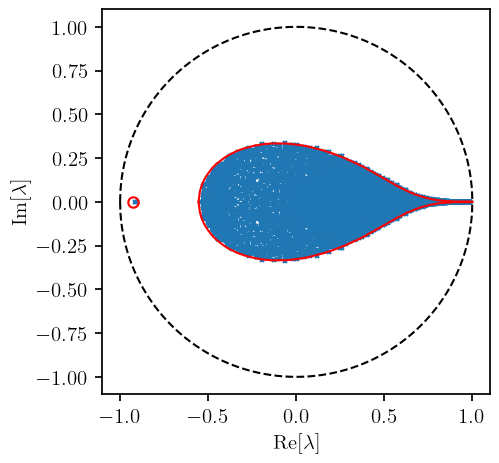

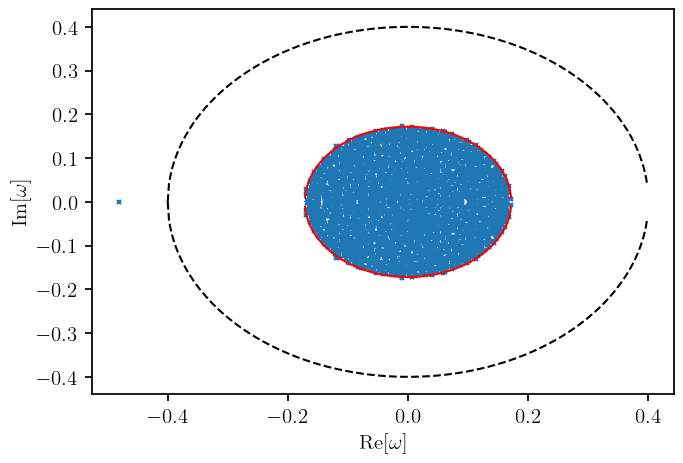

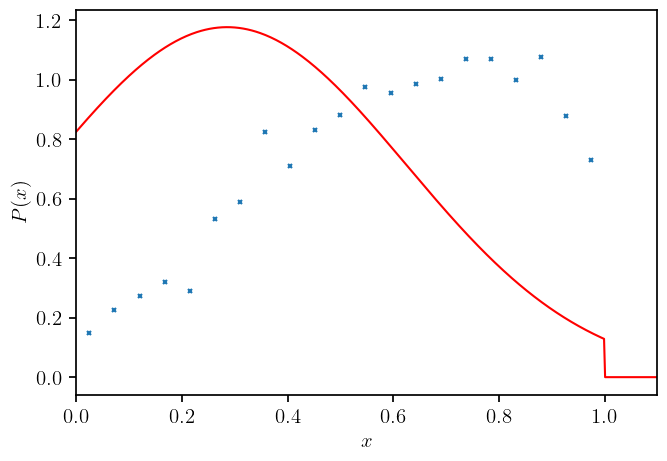

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from itertools import repeat, izip
#from IPython import get_ipython;
#get_ipython().magic('reset -sf')
#plt.close('all')






eff0 = 0.001
effinf = 10.0**5


if __name__ == '__main__':


	xjmin =-1
	xjmax = 1.0
	numbins = 101
	binedges = np.linspace(xjmin, xjmax, numbins+1, endpoint=True)
	binsj = np.linspace(xjmin+float((xjmax-xjmin)/(numbins-1))*0.5, xjmax-float((xjmax-xjmin)/(numbins-1))*0.5, numbins, endpoint=True)		
	diaghist = np.histogram(np.diag(jac), binedges)[0]
	realhist = np.histogram(np.real(evaluesj), binedges)[0]


	xmin = 0
	xmax = 1
	numbins = 21
	binedges = np.linspace(xmin, xmax, numbins+1, endpoint=True)
	bins = np.linspace(xmin+float((xmax-xmin)/(numbins-1))*0.5, xmax-float((xmax-xmin)/(numbins-1))*0.5, numbins, endpoint=True)		
	xhist = np.histogram(xstar, binedges)[0]
	
	#Plotting

	SIZE = 15

	plt.rc('font', size=SIZE)          # controls default text sizes
	plt.rc('axes', titlesize=SIZE)     # fontsize of the axes title
	plt.rc('axes', labelsize=SIZE)    # fontsize of the x and y labels
	plt.rc('xtick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('ytick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('legend', fontsize=SIZE-5)    # legend fontsize
	plt.rc('text', usetex=True)
	plt.rcParams['axes.linewidth'] = 1.25
	plt.rcParams['legend.loc'] = 'best'

	edgewidth = 1.5
	lwidth = 1.25
	size = 7.5
	tickwidth = 1.25
	ticklength = 5
	padness = 5
	fsize = 5


	xvec = np.genfromtxt('xvecjaccutoffmu.csv', dtype = float, delimiter=',', skip_footer=0) 
	yvec = np.genfromtxt('yvecjaccutoffmu.csv', dtype = float, delimiter=',', skip_footer=0)
	yvecellipse = np.genfromtxt('yvecellipsemu.csv', dtype = float, delimiter=',', skip_footer=0)
	xvecellipse = np.genfromtxt('xvecellipsemu.csv', dtype = float, delimiter=',', skip_footer=0)
	outlier = np.genfromtxt('outlierloc.csv', dtype = float, delimiter=',', skip_footer=0)

	'''xvectest = np.genfromtxt('xvecjaccutoff_test.csv', dtype = float, delimiter=',', skip_footer=0)
	yvectest = np.genfromtxt('yvecjaccutoff_test.csv', dtype = float, delimiter=',', skip_footer=0)
	yvecapproxtest = np.genfromtxt('yvecjaccutoff_approx_test.csv', dtype = float, delimiter=',', skip_footer=0)'''

	myx = np.linspace(-1, 1, 1001, endpoint=True)
	
	histvecth = np.genfromtxt('histvecth.csv', dtype = float, delimiter=',', skip_footer=0)
	xvecth = np.genfromtxt('xvecth.csv', dtype = float, delimiter=',', skip_footer=0)

	it = 0

	fig1 = plt.figure(figsize=(5,5))
	ax1 = fig1.add_subplot(111)
	#ax1.plot(np.real(evaluesj), np.imag(evaluesj), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(np.real(myevalues[it*n:(it+1)*n+1]), np.imag(myevalues[it*n:(it+1)*n+1]), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(outlier, 0.0, 'o', markerfacecolor= 'none', color= 'r', markersize = (size ), markeredgewidth = edgewidth)
	#ax1.plot(np.real(evaluesj2), np.imag(evaluesj2), '+', color = 'g', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvec, yvec, '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvec, -yvec, '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(myx, np.sqrt(1.0-myx**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(myx, -np.sqrt(1.0-myx**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\lambda]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\lambda]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	#plt.savefig("jacbianspectrumbounded_sigma0point2_r3point4_mu0point6_square.svg", format="svg")


	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesa), np.imag(evaluesa), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvecellipse, yvecellipse, '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvecellipse, -yvecellipse, '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(myx, np.sqrt((1.0-mu)**2-myx**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(myx, -np.sqrt((1.0-mu)**2-myx**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	#plt.savefig("rimspectrumbounded.svg", format="svg")
	

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(bins, xhist/float(n)*float(numbins)/(xmax-xmin), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvecth, histvecth, '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	axes.set_xlim([0.0,1.1])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$x$")
	ax1.set_ylabel(r"$P(x)$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	#plt.savefig("statdistbounded.svg", format="svg")


	

In [8]:
print(lambdavec.shape)
print(sigmavec.shape)

(5, 21)
(50,)


In [11]:
print(sum(kvec**2))
print(sum(kvec)**2)

29339.0
9979281.0


In [15]:
gammavec

array([-0.8, -0.5, -0.2,  0.1,  0.4])

In [9]:
x = 1.2
np.heaviside(1-x, 0.0)

np.float64(0.0)

In [7]:
np.savetxt("lambdaversussigmavariousgamman1000numtrial10mu0point6imitation.csv", lambdavec, delimiter=",")
np.savetxt("mulversussigmavariousgamman1000numtrial10mu0point6imitation.csv", mulvec, delimiter=",")
#np.savetxt("gammalversussigmavariousgamman1000numtrial10.csv", gammalvec, delimiter=",")
np.savetxt("slversussigmavariousgamman1000numtrial10mu0point6imitation.csv", slvec, delimiter=",")
np.savetxt("s3lversussigmavariousgamman1000numtrial10mu0point6imitation.csv", s3lvec, delimiter=",")
np.savetxt("sigmavecimitation.csv", sigmavec, delimiter=",")

In [53]:
rlvecth

array([[-6.99790528e-04, -2.91533763e-03, -8.95305777e-03,
        -2.19577038e-02, -4.56424525e-02, -8.39982420e-02,
        -1.41277182e-01, -2.22214284e-01, -3.32393627e-01,
        -4.78704839e-01, -6.69886872e-01, -9.17190409e-01,
        -1.23521155e+00, -1.64296688e+00, -2.16529993e+00,
        -2.83473554e+00, -3.69393468e+00, -4.79895117e+00,
        -6.22355748e+00, -8.06499502e+00, -1.04516219e+01],
       [-8.59765613e-04, -2.30321004e-03, -5.28679624e-03,
        -1.06992952e-02, -1.95464610e-02, -3.28654128e-02,
        -5.16665195e-02, -7.69136068e-02, -1.09536372e-01,
        -1.50462721e-01, -2.00660275e-01, -2.61180535e-01,
        -3.33203060e-01, -4.18079514e-01, -5.17378869e-01,
        -6.32935620e-01, -7.66903175e-01, -9.21814728e-01,
        -1.10065408e+00, -1.30693912e+00, -1.54482108e+00],
       [-1.05222654e-03, -2.20462354e-03, -4.21083258e-03,
        -7.42731721e-03, -1.22359646e-02, -1.90135184e-02,
        -2.81065184e-02, -3.98159935e-02, -5.43923788e